In [ ]:
import os
from getpass import getpass



os.environ['HF_TOKEN'] = getpass('Enter your HF Write Token: ')
os.environ['GROQ_API_KEY'] = getpass('Enter your Groq API Key: ')
os.environ['ENV_BASE_URL'] = 'https://aditi75432-zero-trust-safe-SRE-gym.hf.space'
os.environ['USE_EPISODE_REWARDS'] = '0'
print("Secrets set.")

Enter your HF Write Token: ··········
Enter your Groq API Key: ··········
Secrets set.


In [ ]:
# 1. Nuke the conflicted versions
!pip uninstall -y unsloth unsloth_zoo transformers trl peft accelerate

# 2. Install the latest master branch of Unsloth and force the latest transformers
!pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --upgrade --no-cache-dir transformers unsloth_zoo


# # 1. Upgrade pip first to ensure it can handle modern dependency resolution
# !pip install --upgrade pip -q

# # 2. Install Unsloth directly from their source branch, letting it resolve Transformers/PEFT/TRL versions natively
# # Update Unsloth and Unsloth Zoo to their latest emergency patches
# !pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install --upgrade --no-cache-dir --no-deps unsloth_zoo

# # 2. Pin transformers to the last known stable version before the break
# !pip install transformers==4.48.3

# # 3. Setup your environment bridges
import os
import torch



print("Dependencies installed successfully.")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print('Dependencies installed.')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dependencies installed successfully.
GPU: Tesla T4
Dependencies installed.


In [ ]:
import torch
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE"}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else '')


GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
SYSTEM_PROMPT = """You are an autonomous Zero Trust SRE agent. Your job is to identify and contain security incidents in a microservices network.

AVAILABLE TOOLS:
1. query_siem_logs  -- payload: {"node": "<node_name>"}
   Investigate SIEM telemetry on a specific node. Do this FIRST to find evidence.

2. file_ticket      -- payload: {"node": "<node>", "justification": "<specific evidence>"}
   File an ITIL change ticket. Cite the exact IP address, IAM role name, and anomaly
   from your SIEM investigation. Vague justifications will be rejected.

3. check_approval   -- payload: {"ticket_id": "<INC-XXXX>"}
   Verify change board authorization before any isolation.

4. isolate_node     -- payload: {"node": "<node_name>"}
   Quarantine the compromised node. REQUIRES an approved ticket -- no exceptions.
   Attempting isolation without approval triggers immediate -20 penalty.

NODES: api_gateway, auth_service, frontend, payment, hr_db

MANDATORY SEQUENCE: query_siem_logs -> file_ticket -> check_approval -> isolate_node

IMPORTANT: Read the active alerts carefully. FATAL alerts point to the real threat.
WARNING alerts are often false positives. Start with FATAL targets.

Respond with EXACTLY ONE JSON object, nothing else:
{"tool_name": "<tool>", "payload": {"node": "<name>"}, "justification": "<reason>"}
The JSON must be COMPLETE and end with }.
Do not generate anything after the closing brace.
"""

In [ ]:
def build_obs_text(obs):
    alerts = obs.get("active_alerts", [])
    alerts_text = "\n".join(
        f"  [{a['severity']}] {a['target_node']}: {a['symptom'][:100]}"
        for a in alerts
    ) if alerts else "  None"
    ticket_id = obs.get("active_ticket_id")
    ticket_approved = obs.get("ticket_approved", False)
    if ticket_id and ticket_approved:
        ticket_status = f"{ticket_id} (APPROVED -- ready to isolate)"
    elif ticket_id:
        ticket_status = f"{ticket_id} (pending approval)"
    else:
        ticket_status = "None"
    command_out = obs.get("command_output", "Awaiting first command.")
    if len(command_out) > 400:
        command_out = command_out[:400] + "...[truncated]"
    return (
        f"===== SYSTEM STATE =====\n\n"
        f"ACTIVE ALERTS:\n{alerts_text}\n\n"
        f"[CONSEQUENCE OF YOUR LAST ACTION]:\n{command_out}\n\n"
        f"UPTIME: {obs.get('global_uptime', 100.0):.1f}%\n"
        f"TICKET STATUS: {ticket_status}\n"
        f"DIFFICULTY: {obs.get('difficulty', 'warmup')}\n"
        f"JUDGE: {obs.get('judge_persona', 'senior')}\n"
        f"STEP: {obs.get('episode_number', 0)}\n"
    )

In [ ]:
def parse_action(text):
    text = text.strip()
    text = re.sub(r'```(?:json)?', '', text).strip().rstrip('`').strip()
    try:
        parsed = json.loads(text)
        if "tool_name" in parsed:
            if "payload" not in parsed:
                parsed["payload"] = {}
            if "justification" not in parsed:
                parsed["justification"] = ""
            return parsed
    except:
        pass
    match = re.search(r'\{[^{}]*"tool_name"[^{}]*\}', text, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            if "payload" not in parsed:
                parsed["payload"] = {}
            return parsed
        except:
            pass
    tool = "query_siem_logs"
    candidate_nodes = ["frontend", "payment", "hr_db", "api_gateway", "auth_service"]
    node = random.choice(candidate_nodes)
    for n in candidate_nodes:
        if n in text.lower():
            node = n
            break
    if "isolate" in text.lower():
        tool = "isolate_node"
    elif "ticket" in text.lower() or "file" in text.lower():
        tool = "file_ticket"
    elif "approval" in text.lower() or "check" in text.lower():
        tool = "check_approval"
    just_match = re.search(r'justification["\s:]+([^"}{,\n]+)', text, re.IGNORECASE)
    justification = just_match.group(1).strip()[:200] if just_match else "Parsed from free text output."
    return {"tool_name": tool, "payload": {"node": node}, "justification": justification}

In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-1.5B-Instruct",
    max_seq_length=1536,   # shorter for SFT
    load_in_4bit=True,
    dtype=None,
    device_map="auto",
)
model = FastLanguageModel.get_peft_model(
    model,
    r=8,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)
tokenizer.pad_token = tokenizer.eos_token
print('Model loaded for SFT')

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model loaded for SFT


In [ ]:

# PHASE 0.1: ENVIRONMENT SMOKE TEST
# Proves the environment is live and rewards a perfect workflow.

import requests
import os

base_url = os.environ['ENV_BASE_URL']
print("=== Environment Smoke Test ===")

# Reset
obs = requests.post(f"{base_url}/reset", json={"task_id": "auto"}).json()
print(f"Difficulty: {obs.get('difficulty')} | Judge: {obs.get('judge_persona')}")

fatal_alerts = [a for a in obs.get('active_alerts', []) if a['severity'] == 'FATAL']
target = fatal_alerts[0]['target_node'] if fatal_alerts else 'frontend'

print("\\n--- Simulating Perfect Workflow ---")

# Step 1: Investigate
r1 = requests.post(f"{base_url}/step", json={
    "tool_name": "query_siem_logs",
    "payload": {"node": target},
    "justification": "Investigating FATAL alert"
}).json()
print(f"Step 1: query_siem_logs({target}) -> Reward: {r1['reward']['value']:+.1f}")

# Step 2: Ticket
siem_out = r1['observation']['command_output'][:150]
r2 = requests.post(f"{base_url}/step", json={
    "tool_name": "file_ticket",
    "payload": {"node": target},
    "justification": f"SIEM confirms active threat: {siem_out}"
}).json()
ticket_id = r2['observation'].get('active_ticket_id')
print(f"Step 2: file_ticket({target}) -> Reward: {r2['reward']['value']:+.1f} | Ticket: {ticket_id}")

# Step 3: Approve
r3 = requests.post(f"{base_url}/step", json={
    "tool_name": "check_approval",
    "payload": {"ticket_id": ticket_id},
    "justification": "Verifying authorization"
}).json()
print(f"Step 3: check_approval -> Reward: {r3['reward']['value']:+.1f}")

# Step 4: Isolate
r4 = requests.post(f"{base_url}/step", json={
    "tool_name": "isolate_node",
    "payload": {"node": target},
    "justification": f"Approved ticket {ticket_id} authorizes isolation"
}).json()
print(f"Step 4: isolate_node({target}) -> Reward: {r4['reward']['value']:+.1f}")
print(f"Episode Done: {r4['done']}")
print("Smoke test complete. Environment is fully functional.")

=== Environment Smoke Test ===
Difficulty: warmup | Judge: junior
\n--- Simulating Perfect Workflow ---
Step 1: query_siem_logs(frontend) -> Reward: +9.7
Step 2: file_ticket(frontend) -> Reward: +6.1 | Ticket: INC-2637
Step 3: check_approval -> Reward: +1.7
Step 4: isolate_node(frontend) -> Reward: +30.5
Episode Done: True
Smoke test complete. Environment is fully functional.


In [ ]:
!pip uninstall -y transformers trl peft accelerate
!pip install --no-cache-dir --upgrade "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

In [ ]:

# PHASE 0.2: BASELINE UNTRAINED EVALUATION
# Proves the base model cannot solve the Zero Trust Gym.

from unsloth import FastLanguageModel

# Enable Unsloth's 2x faster native inference mode
FastLanguageModel.for_inference(model)

def run_baseline_episode(env_url, episode_idx):
    obs = requests.post(f"{env_url}/reset", json={"task_id": "auto"}).json()
    done = False
    step = 0
    total_reward = 0.0

    print(f"\\n--- Baseline Episode {episode_idx} ---")
    while not done and step < 8:
        step += 1

        # Format using the exact ChatML template we will use in GRPO
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_obs_text(obs)}
        ]

        inputs = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt"
        ).to("cuda")

        # Generate prediction
        outputs = model.generate(inputs, max_new_tokens=350, use_cache=True, temperature=0.7)
        completion = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

        # Parse and execute
        action = parse_action(completion)
        step_resp = requests.post(f"{env_url}/step", json=action).json()

        obs = step_resp["observation"]
        reward = step_resp["reward"]["value"]
        done = step_resp["done"]
        total_reward += reward

        print(f"Step {step}: {action.get('tool_name')} -> {reward:+.1f} | Msg: {step_resp['reward']['message'][:60]}")

    print(f"Total Reward: {total_reward:+.1f}")
    return total_reward

print("Running 3 baseline episodes with the untrained model...")
baseline_rewards = []
for i in range(1, 4):
    baseline_rewards.append(run_baseline_episode(base_url, i))

print(f"\\nBaseline Average Reward: {sum(baseline_rewards)/len(baseline_rewards):.1f}")
print("Expected result: Severely negative reward due to policy violations.")

# Re-enable training mode for SFT and GRPO
FastLanguageModel.for_training(model)

Running 3 baseline episodes with the untrained model...


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


\n--- Baseline Episode 1 ---


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Step 1: query_siem_logs -> +9.7 | Msg: CRITICAL: Found live threat on frontend. Excellent investiga


...

Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Step 2: query_siem_logs -> -1.3 | Msg: Unknown node: front-end


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Step 3: query_siem_logs -> +9.7 | Msg: CRITICAL: Found live threat on frontend. Excellent investiga
Step 4: isolate_node -> -20.3 | Msg: NO_APPROVED_TICKET
Total Reward: -2.2
\nBaseline Average Reward: -8.5
Expected result: Severely negative reward due to policy violations.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536, padding_idx=151665)
        (layers): ModuleList(
          (0): Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
         

## Phase 1a — Generate SFT Expert Data

Runs scripted perfect-behaviour episodes against the live environment to create
a warm-start dataset. Only episodes with positive total reward are kept.
**Skip this cell if you already have `sft_data.json`.**

In [ ]:
# SFT Data Generation
# Generates expert trajectories that teach the model the JSON format and
# the 4-step workflow before GRPO starts.
# Skip if sft_data.json already exists.

import os, json, requests, time

BASE_URL = os.environ['ENV_BASE_URL']
SFT_OUTPUT = 'sft_data.json'

if os.path.exists(SFT_OUTPUT):
    print(f'sft_data.json already exists — skipping generation.')
else:
    def detect_node(text):
        t = text.lower()
        for n in ['payment', 'frontend', 'hr_db', 'auth_service', 'api_gateway']:
            if n in t: return n
        return 'hr_db'

    def run_sft_episode():
        r = requests.post(f'{BASE_URL}/reset', json={'task_id': 'auto'}, timeout=45)
        if r.status_code != 200: return None
        obs = r.json()
        messages = [{'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': build_obs_text(obs)}]
        total_reward = 0.0
        alerts = obs.get('active_alerts', [])
        targets = [a['target_node'] for a in alerts if a.get('severity') == 'FATAL']
        nodes = list(dict.fromkeys(targets + ['hr_db', 'payment', 'frontend']))
        evidence_map = {}
        done = False
        for node in nodes:
            if done: break
            action = {'tool_name': 'query_siem_logs', 'payload': {'node': node},
                      'justification': f'Investigating {node} based on FATAL alerts'}
            messages.append({'role': 'assistant', 'content': json.dumps(action)})
            r2 = requests.post(f'{BASE_URL}/step', json=action, timeout=45)
            if r2.status_code != 200: return None
            data = r2.json()
            obs = data['observation']; total_reward += data['reward']['value']; done = data['done']
            messages.append({'role': 'user', 'content': build_obs_text(obs)})
            if data['reward']['value'] > 0:
                evidence_map[node] = obs.get('command_output', '')
        if not evidence_map: return None
        for node, evidence in evidence_map.items():
            if done: break
            for tool, extra in [
                ('file_ticket',   {'node': node, 'justification': f'SIEM confirms: {evidence[:180]}'}),
                ('check_approval', {}),
                ('isolate_node',  {'node': node}),
            ]:
                if done: break
                if tool == 'check_approval':
                    tid = obs.get('active_ticket_id')
                    if not tid: continue
                    extra = {'ticket_id': tid}
                action = {'tool_name': tool, 'payload': extra, 'justification': 'Expert action'}
                messages.append({'role': 'assistant', 'content': json.dumps(action)})
                r3 = requests.post(f'{BASE_URL}/step', json=action, timeout=45)
                if r3.status_code != 200: return None
                data = r3.json()
                obs = data['observation']; total_reward += data['reward']['value']; done = data['done']
                messages.append({'role': 'user', 'content': build_obs_text(obs)})
        return {'messages': messages, 'total_reward': total_reward}

    results = []
    print('Generating 80 expert episodes for SFT warm-start...')
    for i in range(80):
        ep = run_sft_episode()
        if ep and ep['total_reward'] > 0:
            results.append(ep)
        if (i+1) % 10 == 0:
            print(f'  {i+1}/80 — kept {len(results)} so far')
    with open(SFT_OUTPUT, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Saved {len(results)} expert episodes to {SFT_OUTPUT}')


## Phase 1b — SFT Warm-Start

Trains one epoch on the expert trajectories so the model learns the JSON format
and the workflow sequence before GRPO begins. This eliminates the cold-start problem.

In [ ]:
import json, torch
from datasets import Dataset
from transformers import TrainingArguments, Trainer

with open('sft_data.json', 'r') as f:
    sft_raw = json.load(f)
print(f'Loaded {len(sft_raw)} expert episodes')

IGNORE_INDEX = -100

def build_sft_sample(episode):
    input_ids, labels = [], []
    for msg in episode['messages']:
        role = msg['role']
        content = msg['content']
        if role == 'system':
            text = f"<|system|>\n{content}\n"
            toks = tokenizer.encode(text, add_special_tokens=False)
            input_ids.extend(toks); labels.extend([IGNORE_INDEX]*len(toks))
        elif role == 'user':
            text = f"<|user|>\n{content}\n"
            toks = tokenizer.encode(text, add_special_tokens=False)
            input_ids.extend(toks); labels.extend([IGNORE_INDEX]*len(toks))
        elif role == 'assistant':
            text = f"<|assistant|>\n{content}\n"
            toks = tokenizer.encode(text, add_special_tokens=False)
            input_ids.extend(toks); labels.extend(toks)
    input_ids.append(tokenizer.eos_token_id)
    labels.append(tokenizer.eos_token_id)
    max_len = 1536
    return {'input_ids': input_ids[:max_len], 'labels': labels[:max_len]}

sft_dataset = Dataset.from_list([build_sft_sample(ep) for ep in sft_raw])

def sft_collate(batch):
    max_len = max(len(s['input_ids']) for s in batch)
    padded_ids, padded_labels, attn_masks = [], [], []
    for s in batch:
        pad_len = max_len - len(s['input_ids'])
        padded_ids.append(s['input_ids'] + [tokenizer.pad_token_id]*pad_len)
        padded_labels.append(s['labels'] + [IGNORE_INDEX]*pad_len)
        attn_masks.append([1]*len(s['input_ids']) + [0]*pad_len)
    return {
        'input_ids': torch.tensor(padded_ids, dtype=torch.long),
        'labels': torch.tensor(padded_labels, dtype=torch.long),
        'attention_mask': torch.tensor(attn_masks, dtype=torch.long),
    }

training_args = TrainingArguments(
    output_dir='./sft-checkpoint',
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    warmup_steps=5,
    logging_steps=5,
    save_steps=999,
    report_to='none',
    fp16=True,
    bf16=False,
    dataloader_num_workers=0,
    remove_unused_columns=False,
)

trainer = Trainer(model=model, args=training_args, train_dataset=sft_dataset, data_collator=sft_collate)
trainer.train()
model.gradient_checkpointing_disable()
print('SFT warm-start complete')

Loaded 58 expert episodes


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 58 | Num Epochs = 1 | Total steps = 15
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 9,232,384 of 1,552,946,688 (0.59% trained)


Step,Training Loss
5,0.873734
10,0.818655
15,0.813482


SFT warm-start complete


## Phase 2 — GRPO Setup: Prompt Collection + Reward Function

In [ ]:
import time, random, json, requests
from datasets import Dataset

BASE_URL = os.environ['ENV_BASE_URL']

def collect_prompts(n_prompts=50):
    print(f"[Dataset] Collecting {n_prompts} prompts from environment...")
    prompts = []
    actions = [{"tool_name":"query_siem_logs","payload":{"node":n},"justification":"investigating"} for n in ["hr_db","payment","frontend","api_gateway"]]
    while len(prompts) < n_prompts:
        try:
            resp = requests.post(f"{BASE_URL}/reset", json={"task_id":"auto"}, timeout=40)
            if resp.status_code != 200:
                print(f"[Rate Limit] Cooling down... ({len(prompts)}/{n_prompts})")
                time.sleep(10)
                continue
            obs = resp.json()
            done = False
            step = 0
            while not done and step < 8 and len(prompts) < n_prompts:
                step += 1
                messages = [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": build_obs_text(obs)}
                ]
                prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
                prompts.append({"prompt": prompt_text})
                step_resp = requests.post(f"{BASE_URL}/step", json=random.choice(actions), timeout=40)
                if step_resp.status_code != 200: break
                obs = step_resp.json()["observation"]
                done = step_resp.json()["done"]
        except Exception as e:
            print(f"[Network] Error: {e}. Retrying in 5s...")
            time.sleep(5)
    print(f"[Dataset] Done. {len(prompts)} prompts collected.")
    return Dataset.from_list(prompts[:n_prompts])


class ZeroTrustStepReward:
    def __init__(self, base_url):
        self.base_url = base_url
        self._call_count = 0

    def _reset(self):
        try:
            resp = requests.post(f"{self.base_url}/reset", json={"task_id":"auto"}, timeout=10)
            return resp.json() if resp.status_code == 200 else {}
        except:
            return {}

    def __call__(self, completions, **kwargs):
        self._call_count += 1
        rewards = []
        for completion in completions:
            self._reset()
            action = parse_action(completion)
            try:
                parsed = json.loads(completion.strip())
                format_bonus = 0.5 if "tool" in parsed else 0.0
            except:
                format_bonus = -0.5
            try:
                resp = requests.post(f"{self.base_url}/step", json=action, timeout=30)
                if resp.status_code == 200:
                    data = resp.json()
                    reward = float(data["reward"]["value"]) + format_bonus
                    rewards.append(reward)
                else:
                    rewards.append(-1.0)
            except:
                rewards.append(-1.0)
        if self._call_count % 10 == 0:
            mean_r = sum(rewards)/len(rewards) if rewards else 0
            print(f"[Reward] Step-mode call {self._call_count} mean={mean_r:.2f}")
        return rewards

In [ ]:
def json_format_reward(completions, **kwargs):
    rewards = []
    for completion in completions:
        try:
            parsed = json.loads(completion.strip())
            if "tool_name" in parsed and "payload" in parsed:
                rewards.append(2.0)
            else:
                rewards.append(-5.0)
        except:
            rewards.append(-5.0)
    return rewards

In [ ]:
# Collect prompts
dataset = collect_prompts(n_prompts=50)   # adjust as needed

# Reward function
reward_obj = ZeroTrustStepReward(os.environ['ENV_BASE_URL'])

[Dataset] Collecting 50 prompts from environment...
[Dataset] Done. 50 prompts collected.


## Phase 2 — GRPO Training

Uses two reward functions:
1. `ZeroTrustStepReward` — queries the live environment for real rewards
2. `json_format_reward` — independently verifies JSON format compliance

The dual-reward approach makes it much harder for the agent to reward-hack.

In [ ]:
from trl import GRPOConfig, GRPOTrainer
import torch, re, json, time, random, requests

training_args = GRPOConfig(
    output_dir="./grpo-checkpoint",
    max_steps=100,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=1.5e-5,
    warmup_steps=10,
    num_generations=8,
    generation_batch_size=8,
    temperature=0.9,
    max_completion_length=350,   # critical
    logging_steps=1,
    save_steps=25,
    report_to="none",
    bf16=False,
    fp16=True,
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    reward_funcs=[reward_obj.__call__, json_format_reward],
    train_dataset=dataset,
    processing_class=tokenizer,
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50 | Num Epochs = 2 | Total steps = 100
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 9,232,384 of 1,552,946,688 (0.59% trained)
Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / __call__ / mean,rewards / __call__ / std,rewards / json_format_reward / mean,rewards / json_format_reward / std
1,0.000000,-17.237499,12.140363,122.500000,39.000000,199.000000,0.000000,122.500000,39.000000,199.000000,0.000357,-13.987499,9.441313,-3.250000,3.240370
2,0.000000,-14.674999,12.377254,107.875000,40.000000,192.000000,0.000000,107.875000,40.000000,192.000000,0.000442,-11.424999,10.059643,-3.250000,3.240370
3,0.000000,-16.049999,13.474844,154.875000,55.000000,222.000000,0.000000,154.875000,55.000000,222.000000,0.000387,-13.674999,9.858825,-2.375000,3.622844
4,0.000000,-25.799999,0.000000,202.625000,150.000000,336.000000,0.000000,202.625000,150.000000,336.000000,0.000245,-20.799999,0.000000,-5.000000,0.000000
5,0.000001,-13.362499,17.627975,144.000000,35.000000,350.000000,0.125000,114.571434,35.000000,173.000000,0.000553,-10.987499,14.124290,-2.375000,3.622844
6,0.000000,-25.799999,0.000000,218.000000,158.000000,334.000000,0.000000,218.000000,158.000000,334.000000,0.000252,-20.799999,0.000000,-5.000000,0.000000
7,0.000000,-15.674999,13.973827,118.125000,37.000000,170.000000,0.000000,118.125000,37.000000,170.000000,0.000309,-13.299999,10.350983,-2.375000,3.622844
8,0.000001,-6.362500,16.691395,105.375000,33.000000,250.000000,0.000000,105.375000,33.000000,250.000000,0.000709,-5.737500,13.232637,-0.625000,3.622844
9,0.000001,-12.549999,14.164845,142.750000,40.000000,277.000000,0.000000,142.750000,40.000000,277.000000,0.000943,-11.049999,10.423188,-1.500000,3.741657
10,0.000002,-15.737499,14.934231,164.000000,47.000000,238.000000,0.000000,164.000000,47.000000,238.000000,0.002037,-12.487499,12.115332,-3.250000,3.240370


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=3

[Reward] Step-mode call 10 mean=-12.49


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

[Reward] Step-mode call 90 mean=5.64


Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=350) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

[Reward] Step-mode call 100 mean=9.70


Unsloth: Restored added_tokens_decoder metadata in ./grpo-checkpoint/checkpoint-100/tokenizer_config.json.


TrainOutput(global_step=100, training_loss=2.284154102596858e-05, metrics={'train_runtime': 10392.187, 'train_samples_per_second': 0.077, 'train_steps_per_second': 0.01, 'total_flos': 0.0, 'train_loss': 2.284154102596858e-05})

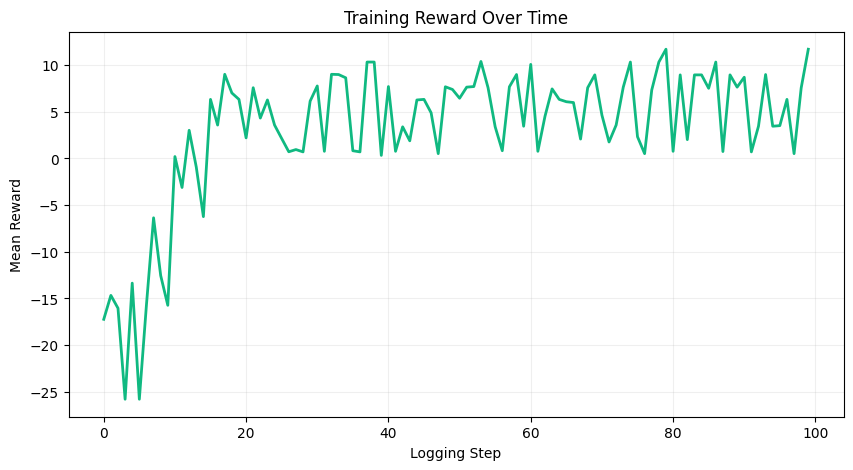

In [ ]:
import matplotlib.pyplot as plt

reward_log = []
for log in trainer.state.log_history:
    if 'reward' in log:
        reward_log.append(log['reward'])
if reward_log:
    plt.figure(figsize=(10,5))
    plt.plot(reward_log, color='#10b981', linewidth=2)
    plt.title("Training Reward Over Time")
    plt.xlabel("Logging Step")
    plt.ylabel("Mean Reward")
    plt.grid(True, alpha=0.2)
    plt.savefig("reward_curve.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No reward logs found; using step reward history instead.")

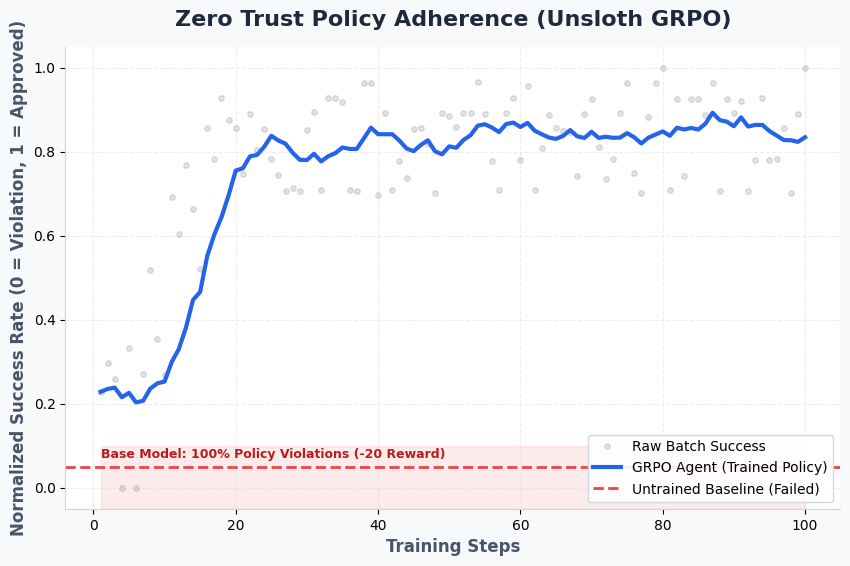

SUCCESS! Saved 'reward_curve_normalized.png'.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the raw reward history from the trainer's logs
log_history = trainer.state.log_history
steps = []
raw_rewards = []

for log in log_history:
    # Use the exact key that generated your green graph
    if 'reward' in log and 'step' in log:
        steps.append(log['step'])
        raw_rewards.append(log['reward'])

if not raw_rewards:
    print("Error: No rewards found in logs. Cannot plot.")
else:
    # 2. Convert to numpy arrays
    steps = np.array(steps)
    raw_rewards = np.array(raw_rewards)

    # 3. Min-Max Normalization (0.0 to 1.0)
    min_r = np.min(raw_rewards)
    max_r = np.max(raw_rewards)
    # Add epsilon (1e-8) to prevent division by zero
    normalized_rewards = (raw_rewards - min_r) / (max_r - min_r + 1e-8)

    # 4. Smooth the curve (Moving Average)
    window = max(1, len(normalized_rewards) // 10) # Dynamic window based on data length
    padded_rewards = np.pad(normalized_rewards, (window-1, 0), mode='edge')
    smoothed_rewards = np.convolve(padded_rewards, np.ones(window)/window, mode='valid')

    # 5. Build a gorgeous, presentation-ready plot
    plt.figure(figsize=(10, 6), facecolor='#f8f9fa')
    ax = plt.gca()
    ax.set_facecolor('#ffffff')

    # Plot the raw normalized data as faint dots
    plt.plot(steps, normalized_rewards, alpha=0.2, color='#6c757d', marker='o', markersize=4, linestyle='none', label='Raw Batch Success')

    # Plot the smoothed trendline as a bold blue line
    plt.plot(steps, smoothed_rewards, color='#2563eb', linewidth=3, label='GRPO Agent (Trained Policy)')

    # BaseLine
    plt.axhline(y=0.05, color='#ef4444', linestyle='--', linewidth=2, label='Untrained Baseline (Failed)')
    plt.fill_between(steps, -0.05, 0.1, color='#ef4444', alpha=0.1)

    # Add an annotation directly on the graph
    plt.text(steps[0], 0.07, "Base Model: 100% Policy Violations (-20 Reward)", color='#b91c1c', fontsize=9, fontweight='bold')

    # Formatting
    plt.title("Zero Trust Policy Adherence (Unsloth GRPO)", fontsize=16, fontweight='bold', pad=15, color='#1e293b')
    plt.xlabel("Training Steps", fontsize=12, fontweight='bold', color='#475569')
    plt.ylabel("Normalized Success Rate (0 = Violation, 1 = Approved)", fontsize=12, fontweight='bold', color='#475569')
    plt.ylim(-0.05, 1.05)

    # Clean grid
    plt.grid(True, linestyle='--', alpha=0.4, color='#cbd5e1')

    # Legend
    legend = plt.legend(loc="lower right", frameon=True, edgecolor='#cbd5e1')
    legend.get_frame().set_alpha(0.9)

    # Remove top and right borders for a modern look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')

    # Save and show
    plt.savefig("reward_curve_normalized.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("SUCCESS! Saved 'reward_curve_normalized.png'.")

## Results — All Three Plots

Generates all three publication-quality graphs and saves them as `.png` files.
These must be committed to the repo root for judge validation.

Generating Final Hackathon Deliverables...


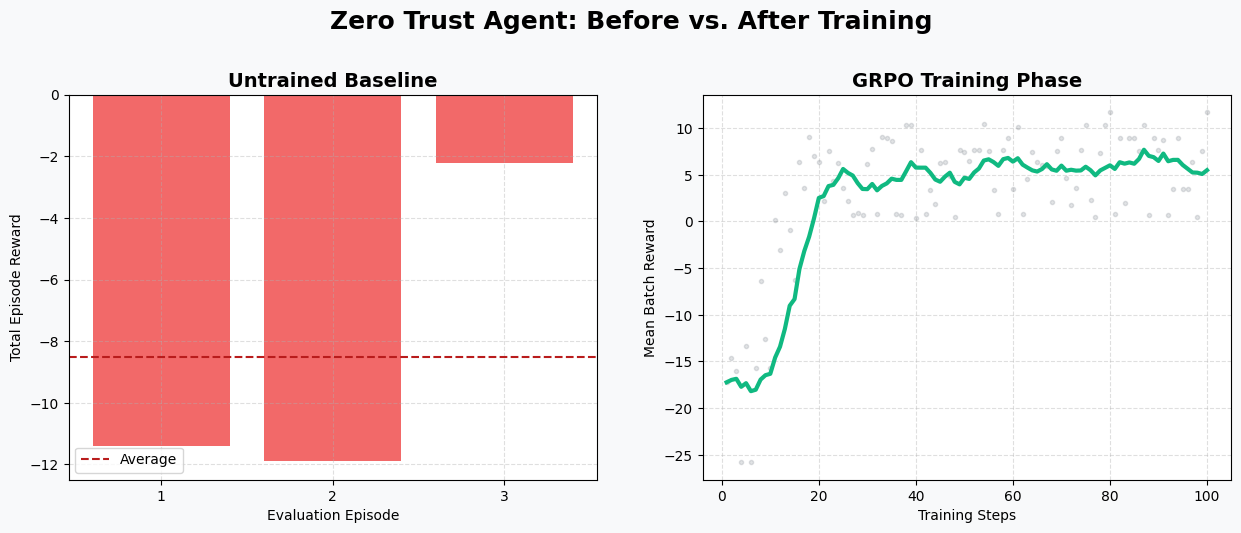

Saved -> graph_1_side_by_side.png


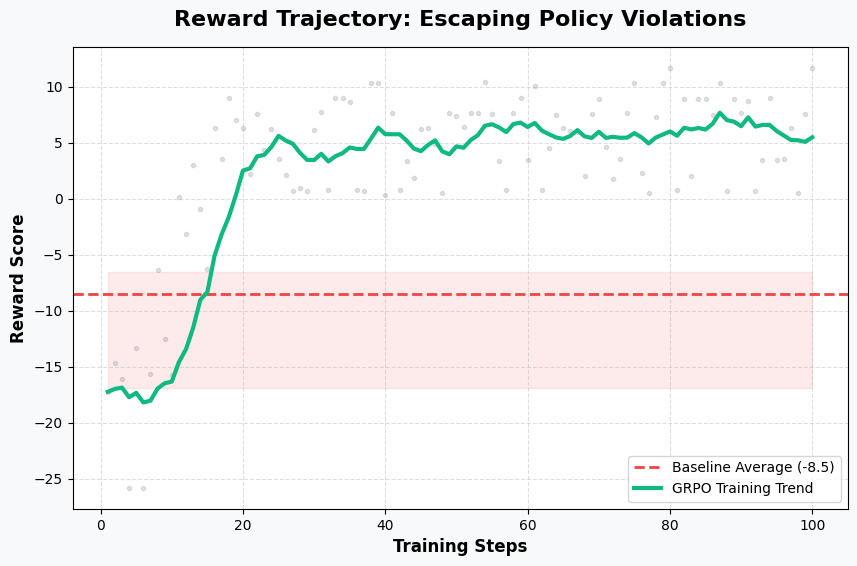

Saved -> graph_2_overlay_raw.png


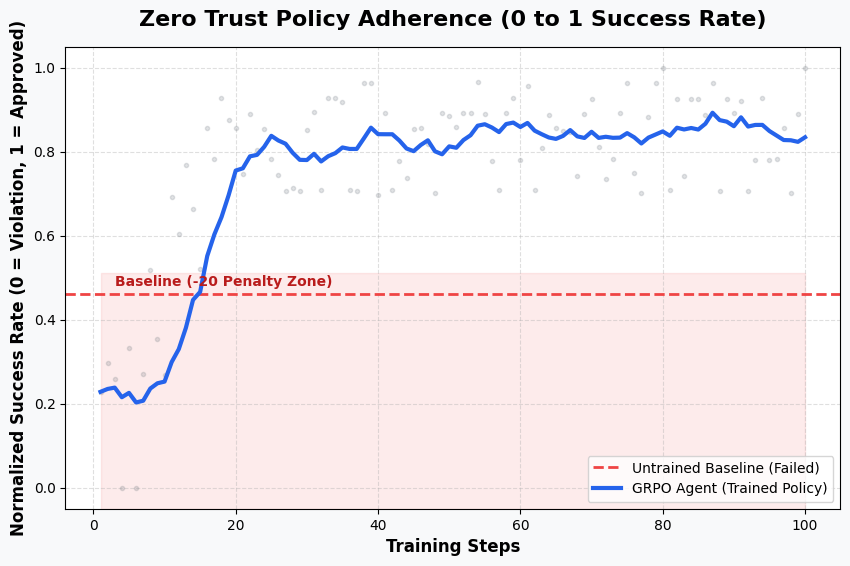

Saved -> graph_3_overlay_normalized.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_training_data(trainer):
    """Extracts raw steps and rewards from the Unsloth GRPO trainer."""
    steps, raw_rewards = [], []
    for log in trainer.state.log_history:
        if 'reward' in log and 'step' in log:
            steps.append(log['step'])
            raw_rewards.append(log['reward'])
    return np.array(steps), np.array(raw_rewards)


# FUNCTION 1: SIDE-BY-SIDE (RAW SCORES)
# Shows the stark contrast between the two phases.

def plot_side_by_side(baseline_rewards, steps, train_rewards):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='#f8f9fa')

    # Left Plot: Baseline (Bar Chart)
    episodes = np.arange(1, len(baseline_rewards) + 1)
    ax1.bar(episodes, baseline_rewards, color='#ef4444', alpha=0.8)
    ax1.axhline(y=np.mean(baseline_rewards), color='#b91c1c', linestyle='--', label='Average')
    ax1.set_title("Untrained Baseline", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Evaluation Episode")
    ax1.set_ylabel("Total Episode Reward")
    ax1.set_xticks(episodes)
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend()

    # Right Plot: Training (Line Chart)
    window = max(1, len(train_rewards) // 10)
    padded = np.pad(train_rewards, (window-1, 0), mode='edge')
    smoothed = np.convolve(padded, np.ones(window)/window, mode='valid')

    ax2.plot(steps, train_rewards, alpha=0.2, color='#6c757d', marker='.', linestyle='none')
    ax2.plot(steps, smoothed, color='#10b981', linewidth=3)
    ax2.set_title("GRPO Training Phase", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Training Steps")
    ax2.set_ylabel("Mean Batch Reward")
    ax2.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle("Zero Trust Agent: Before vs. After Training", fontsize=18, fontweight='bold', y=1.05)
    plt.savefig("graph_1_side_by_side.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved -> graph_1_side_by_side.png")



# FUNCTION 2: OVERLAY IN ONE GRAPH (RAW)
# Drops the baseline average as a flat line across the training steps.

def plot_overlay_raw(baseline_rewards, steps, train_rewards):
    plt.figure(figsize=(10, 6), facecolor='#f8f9fa')
    baseline_avg = np.mean(baseline_rewards)

    window = max(1, len(train_rewards) // 10)
    padded = np.pad(train_rewards, (window-1, 0), mode='edge')
    smoothed = np.convolve(padded, np.ones(window)/window, mode='valid')

    # Baseline Line & Zone
    plt.axhline(y=baseline_avg, color='#ef4444', linestyle='--', linewidth=2, label=f'Baseline Average ({baseline_avg:.1f})')
    plt.fill_between(steps, min(baseline_rewards)-5, baseline_avg+2, color='#ef4444', alpha=0.1)

    # Training Curve
    plt.plot(steps, train_rewards, alpha=0.2, color='#6c757d', marker='o', markersize=3, linestyle='none')
    plt.plot(steps, smoothed, color='#10b981', linewidth=3, label='GRPO Training Trend')

    plt.title("Reward Trajectory: Escaping Policy Violations", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Training Steps", fontsize=12, fontweight='bold')
    plt.ylabel("Reward Score", fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc="lower right")

    plt.savefig("graph_2_overlay_raw.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved -> graph_2_overlay_raw.png")



# FUNCTION 3: OVERLAY IN ONE GRAPH (NORMALIZED 0-1)

def plot_overlay_normalized(baseline_rewards, steps, train_rewards):
    plt.figure(figsize=(10, 6), facecolor='#f8f9fa')

    # Combine data to find true min/max for normalization
    min_r = min(np.min(train_rewards), np.min(baseline_rewards))
    max_r = max(np.max(train_rewards), np.max(baseline_rewards))

    # Normalize baseline average
    baseline_avg = np.mean(baseline_rewards)
    norm_baseline_avg = (baseline_avg - min_r) / (max_r - min_r + 1e-8)

    # Normalize training rewards
    norm_train_rewards = (train_rewards - min_r) / (max_r - min_r + 1e-8)

    window = max(1, len(norm_train_rewards) // 10)
    padded = np.pad(norm_train_rewards, (window-1, 0), mode='edge')
    smoothed = np.convolve(padded, np.ones(window)/window, mode='valid')

    # Baseline Zone
    plt.axhline(y=norm_baseline_avg, color='#ef4444', linestyle='--', linewidth=2, label='Untrained Baseline (Failed)')
    plt.fill_between(steps, -0.05, norm_baseline_avg + 0.05, color='#ef4444', alpha=0.1)

    # Training Curve
    plt.plot(steps, norm_train_rewards, alpha=0.2, color='#6c757d', marker='o', markersize=3, linestyle='none')
    plt.plot(steps, smoothed, color='#2563eb', linewidth=3, label='GRPO Agent (Trained Policy)')

    plt.text(steps[2], norm_baseline_avg + 0.02, f"Baseline (-20 Penalty Zone)", color='#b91c1c', fontsize=10, fontweight='bold')

    plt.title("Zero Trust Policy Adherence (0 to 1 Success Rate)", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Training Steps", fontsize=12, fontweight='bold')
    plt.ylabel("Normalized Success Rate (0 = Violation, 1 = Approved)", fontsize=12, fontweight='bold')
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc="lower right")

    plt.savefig("graph_3_overlay_normalized.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved -> graph_3_overlay_normalized.png")

try:
    train_steps, train_rewards = get_training_data(trainer)
    if len(train_rewards) > 0:
        print("Generating Final Hackathon Deliverables...")
        plot_side_by_side(baseline_rewards, train_steps, train_rewards)
        plot_overlay_raw(baseline_rewards, train_steps, train_rewards)
        plot_overlay_normalized(baseline_rewards, train_steps, train_rewards)
    else:
        print("Error: No training logs found in trainer.")
except Exception as e:
    print(f"Error generating plots: {e}")

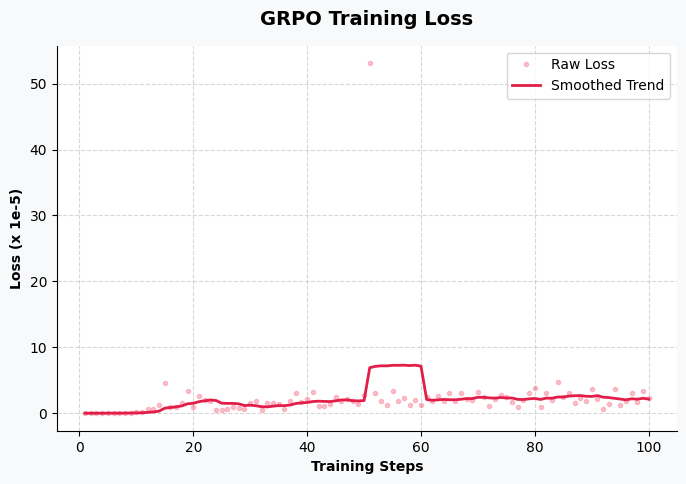

Saved loss_curve.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

#hardcoded as runtime disconnected abruptly :(
steps = list(range(1, 101))
losses = [0.000000, 0.000000, 0.000000, 0.000000, 0.000001, 0.000000, 0.000000, 0.000001, 0.000001, 0.000002, 0.000002, 0.000006, 0.000006, 0.000013, 0.000046, 0.000010, 0.000010, 0.000015, 0.000033, 0.000010, 0.000026, 0.000020, 0.000018, 0.000005, 0.000005, 0.000007, 0.000010, 0.000008, 0.000007, 0.000016, 0.000018, 0.000005, 0.000015, 0.000016, 0.000014, 0.000006, 0.000019, 0.000031, 0.000017, 0.000022, 0.000032, 0.000011, 0.000011, 0.000014, 0.000025, 0.000019, 0.000021, 0.000018, 0.000014, 0.000027, 0.000531, 0.000031, 0.000019, 0.000013, 0.000034, 0.000019, 0.000023, 0.000012, 0.000020, 0.000012, 0.000025, 0.000019, 0.000026, 0.000019, 0.000030, 0.000018, 0.000031, 0.000022, 0.000020, 0.000032, 0.000024, 0.000011, 0.000022, 0.000028, 0.000024, 0.000017, 0.000010, 0.000020, 0.000030, 0.000038, 0.000009, 0.000031, 0.000020, 0.000047, 0.000024, 0.000031, 0.000015, 0.000023, 0.000019, 0.000036, 0.000021, 0.000007, 0.000014, 0.000036, 0.000013, 0.000019, 0.000031, 0.000017, 0.000033, 0.000023]

plt.figure(figsize=(8, 5), facecolor='#f8f9fa')
losses_scaled = np.array(losses) * 100000
window = max(1, len(losses_scaled) // 10)
padded = np.pad(losses_scaled, (window-1, 0), mode='edge')
smoothed_loss = np.convolve(padded, np.ones(window)/window, mode='valid')

plt.plot(steps, losses_scaled, alpha=0.3, color='#f43f5e', marker='.', linestyle='none', label='Raw Loss')
plt.plot(steps, smoothed_loss, color='#e11d48', linewidth=2, label='Smoothed Trend')

plt.title("GRPO Training Loss", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Training Steps", fontweight='bold')
plt.ylabel("Loss (x 1e-5)", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved loss_curve.png")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract Loss from logs
steps = []
losses = []
for log in trainer.state.log_history:
    if 'loss' in log and 'step' in log:
        steps.append(log['step'])
        losses.append(log['loss'])

if losses:
    plt.figure(figsize=(8, 5), facecolor='#f8f9fa')

    # Smooth the loss
    window = max(1, len(losses) // 10)
    smoothed_loss = np.convolve(losses, np.ones(window)/window, mode='valid')

    plt.plot(steps, losses, alpha=0.3, color='#f43f5e', label='Raw Loss')
    plt.plot(steps[window-1:], smoothed_loss, color='#e11d48', linewidth=2, label='Smoothed Trend')

    plt.title("GRPO Training Loss", fontweight='bold')
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved loss_curve.png!.")

In [ ]:
output_path = './zero-trust-sre-final'
model.save_pretrained_merged(output_path, tokenizer, save_method='merged_16bit')
print(f'Model saved to {output_path}')
print('To push to HuggingFace Hub:')
print(f'  model.push_to_hub("your-username/zero-trust-sre-agent", token=os.environ["HF_TOKEN"])')
print(f'  tokenizer.push_to_hub("your-username/zero-trust-sre-agent", token=os.environ["HF_TOKEN"])')
